# Chapter 11 - Advanced Topics and Cutting-Edge Research


These are the libraries we will use for the code examples of Chapter 11.

In [1]:
!pip install -qU smolagents ddgs
!pip install -qU transformers==5.2.0
!pip install -qU huggingface_hub>=1.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 55.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
smolagents 1.24.0 requires huggingface-hub<1.0.0,>=0.31.2

In [2]:
# Very important to be logged in!
from huggingface_hub import login
login()


## Agentic Vision Language Models
### Introduction to Smolagents

Let’s build a tiny agent and watch what happens inside the loop. Smolagents comes with two agent classes, both based on a common MultiStepAgent that contains the ReAct loop.

CodeAgent writes and executes Python to perform actions

ToolCallingAgent outputs JSON to call tools instead, which is the more traditional approach you will find in other frameworks.

Both need tools: smolagents ships with WebSearchTool, PythonInterpreterTool, and a Tool base class for building your own.

Let’s write a trivial tool and run it. Pay attention to the description field: this is what the LLM reads to decide when and how to call your tool.

In [3]:
from smolagents import Tool, CodeAgent, InferenceClientModel, DuckDuckGoSearchTool
import torch

class AdditionTool(Tool):
    name = "addition_tool"
    description = "Adds two numbers together"
    inputs = {
        "first_number": {
            "type": "integer",
            "description": "first number to add"
        },
        "second_number": {
            "type": "integer",
            "description": "second number to add"
        }
    }
    output_type = "integer"

    def forward(self, first_number, second_number):
        return first_number + second_number

model = InferenceClientModel()
agent = CodeAgent(tools=[AdditionTool()], model=model)
result = agent.run("What is 41 plus 1?")


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is 41 plus 1?                                                                                              │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = 41 + 1                                                                                                  
  final_answer(result)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 42

[Step 1: Duration 3.39 seconds| Input tokens: 2,081 | Output tokens: 670]

The output reveals the full lifecycle of an agent run:

In [4]:
for step in agent.memory.steps:
    print(f"{type(step).__name__}: {step}")


TaskStep: TaskStep(task='What is 41 plus 1?', task_images=None)
ActionStep: ActionStep(step_number=1, timing=Timing(start_time=1773324476.1104407, end_time=1773324479.499726, duration=3.3892853260040283), model_input_messages=[ChatMessage(role=<MessageRole.SYSTEM: 'system'>, content=[{'type': 'text', 'text': 'You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.\nTo do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.\nTo solve the task, you must plan forward to proceed in a series of steps, in a cycle of Thought, Code, and Observation sequences.\n\nAt each step, in the \'Thought:\' sequence, you should first explain your reasoning towards solving the task and the tools that you want to use.\nThen in the Code sequence you should write the code in simple Python. The code sequence must be opened with \'<code>\', and closed with \'</code>\'.\nDuring e

Those four classes — TaskStep, PlanningStep, ActionStep, and FinalAnswerStep — are the memory objects that track every agent run. They map directly to the ReAct loop from Figure 11-1:

TaskStep stores the user’s initial instruction (and any input images — this is where screenshots enter the loop for computer-use agents).

PlanningStep stores a high-level plan before execution, if you enable planning. Our toy example skipped it, but for complex tasks (“research three vendors and draft an email”) planning helps the agent stay on track.

ActionStep is the core of the loop. Each cycle of think → act → observe produces one ActionStep containing: the LLM’s reasoning (model_output), which tools were called (tool_calls), what came back as text (observations), and what came back as images (observations_images). That last field is how screenshots flow through the loop in computer-use agents — you will see this in section 11.1.3.

FinalAnswerStep stores the return value when the agent decides it is done.

Now that you have seen the lifecycle in action, let’s look at the different ways to connect models and external capabilities to your agent.

### Leveraging Hugging Face Spaces as tools

Your tools don’t have to be hand-written functions. One of smolagents’ nicest tricks is turning any Hugging Face Space into a callable tool with a single line. Tool.from_space() wraps any of them as a tool your agent can call mid-loop.

For example, let’s give our agent access to FLUX.1-schnell, a fast image generation model:



Loaded as API: https://black-forest-labs-flux-1-dev.hf.space ✔


/usr/local/lib/python3.12/dist-packages/smolagents/tools.py:666: UserWarning: Since `api_name` was not defined, it was automatically set to the first available API: `/infer`.
  warnings.warn(


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a futuristic city with flying cars at sunset                                               │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator(                                                                                         
      prompt="Futuristic cityscape at sunset with flying cars, glowing neon signs, tall skyscrapers, vibrant       
  orange and purple sky, cinematic lighting, highly detailed, photorealistic style",                               
      seed=42,                                                                                                     
      randomize_seed=True,                                                                                         
      width=512,                                                                                                   
      height=512,                                                                                                  
      guidance_scale=7.5,                                                                                          
      num_inference_steps=50                                                                                       
  )                                                                                                                
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator(                                                                                         
      prompt="Futuristic cityscape at sunset with flying cars, glowing neon signs, tall skyscrapers, vibrant       
  orange and purple sky, cinematic lighting",                                                                      
      seed=42,                                                                                                     
      randomize_seed=True,                                                                                         
      width=256,                                                                                                   
      height=256,                                                                                                  
      guidance_scale=7.0,                                                                                          
      num_inference_steps=30                                                                                       
  )                                                                                                                
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: /tmp/gradio/bf12ae40151c5b5b849ebd24b75083cda7cff290b1d760d5e3e3bb1734078400/image.webp

[Step 2: Duration 20.28 seconds| Input tokens: 6,525 | Output tokens: 3,577]

ValueError: Cannot embed the 'webp' image format

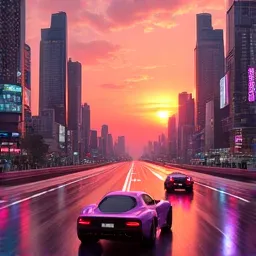

In [5]:
image_gen_tool = Tool.from_space(
    space_id="black-forest-labs/FLUX.1-dev",
    name="image_generator",
    description="Generates an image following your prompt. Returns the image.")

agent = CodeAgent(tools=[image_gen_tool], model=model)

agent.run("Generate an image of a futuristic city with flying cars at sunset")


The agent writes code that calls image_generator(prompt=”...”), receives the generated image as an observations_images entry in its ActionStep, and can then reason about it or return it as the final answer. The same pattern works for any Space: swap in a speech-to-text Space and your agent can transcribe audio, swap in a document OCR Space and it can read PDFs. The key insight is that models become tools, your agent doesn’t need to do everything itself, it just needs to know which specialist to call.



### Connecting your model

You may have noticed we have been writing model=model in every snippet without explaining where it comes from. That’s because smolagents is model-agnostic: it doesn’t care whether your LLM runs on your laptop, on a rented GPU, or behind an API. You just need to pick the right wrapper class for your setup.

For local models, smolagents offers three options depending on your hardware:

TransformersModel: runs models locally via the transformers library, e.g. TransformersModel(model_id="Qwen/Qwen2.5-Coder-32B-Instruct”, device="cuda”)

MLXModel: optimized for Apple Silicon (M1/M2/M3/M4) using the mlx library, e.g. MLXModel(model_id="mlx-community/Llama-3.2-3B-Instruct-4bit”)

VLLMModel: connects to a vLLM server, useful when you want to serve a model once and share it across multiple agents or applications.

For hosted models, you have three more:

InferenceClientModel
Connects to Hugging Face Inference Providers, a router that gives you access to models served by multiple providers. Hugging Face also offers Inference Endpoints, where you rent a dedicated instance for any model. This class works with both, e.g. InferenceClientModel(model_id="moonshotai/Kimi-K2-Thinking”)

OpenAIServerModel
Connects to OpenAI’s API or any OpenAI-compatible endpoint.

LiteLLMModel
A wrapper around LiteLLM that lets you call almost any API (Anthropic, Gemini, Bedrock, Mistral, etc.) through a unified interface.

In practice, InferenceClientModel is the fastest way to get started: it doesen’t require a beefy computer and third party APIs but just a Hugging Face token. Here is a complete working example:

In [7]:
model = InferenceClientModel()
agent = CodeAgent(
	tools=[DuckDuckGoSearchTool()],
	model=model
	)
result = agent.run("What is the current weather in Paris?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is the current weather in Paris?                                                                           │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  search_results = web_search(query="current weather in Paris")                                                    
  print(search_results)                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[Daily Forecast Paris, France· as of 4:00 AM 
PDT](https://weather.com/weather/tenday/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
Be prepared with the most accurate 10-day forecast for Paris, France with highs, lows, chance of precipitation from
The Weather Channel and Weather.com

[Paris, Ville de Paris, France Weather Forecast | 
AccuWeather](https://www.accuweather.com/en/fr/paris/623/weather-forecast/623)
Paris, Ville de Paris, France Weather Forecast, with current conditions, wind, air quality, and what to expect for 
the next 3 days.

[Weather 
Today](https://weather.com/weather/today/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
January 8, 2026 -Today’s and tonight’s Paris, France weather forecast, weather conditions and Doppler radar from 
The Weather Channel and weather.com

[Hourly Weather Paris, France · as of 4:00 PM 
PST](https://weather.com/weather/hourbyhour/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
Hourly Local Weather Forecast, weather conditions, precipitation, dew point, humidity, wind from weather.com and 
The Weather Channel

[Paris, France 10-Day Weather Forecast | Weather Underground](https://www.wunderground.com/forecast/fr/paris)
Paris Weather Forecasts. Weather Underground provides local & long-range weather forecasts, weatherreports, maps & 
tropical weather conditions for the Paris area.

[Paris (France) weather - Met Office](https://weather.metoffice.gov.uk/forecast/u09tvnxyj)
January 8, 2026 -Paris 7 day weather forecast including weather warnings, temperature, rain, wind, visibility, 
humidity and UV

[Weather – WHIO TV 7 and WHIO Radio](https://www.whio.com/weather/)
1 day ago -24/7 Dayton weather with forecasts, radar, weather alerts and how to keep your family safe during severe
storms.

[Paris, IDF, FR Current Weather - The Weather 
Network](https://www.theweathernetwork.com/en/city/fr/ile-de-france/paris/current)
Get Paris, IDF, FR current weather report with temperature, feels like, wind, humidity, pressure, UV and more from 
TheWeatherNetwork.com.

[Weather 
Tenday](https://weather.com/weather/tenday/l/d2a540efb4e9604b3c1d01b7851a1d9d2ab4c7b3ba428e5799936ac54404c035)
Be prepared with the most accurate 10-day forecast for Paris, Île-de-France, France with highs, lows, chance of 
precipitation from The Weather Channel and Weather.com

[Yr - Paris - Hourly weather 
forecast](https://www.yr.no/en/forecast/hourly-table/2-2988507/France/Île-de-France+Region/Paris+Department/Paris?i
=0)
Today's weather forecast for Paris by the hour.

Out: None

[Step 1: Duration 8.24 seconds| Input tokens: 2,085 | Output tokens: 1,768]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import re                                                                                                        
  search_results = web_search(query="current weather in Paris")                                                    
  match = re.search(r'(\d+)\s*°C', search_results)                                                                 
  if match:                                                                                                        
      temperature = match.group(1) + "°C"                                                                          
      final_answer(temperature)                                                                                    
  else:                                                                                                            
      match = re.search(r'(\d+)\s*degrees', search_results)                                                        
      if match:                                                                                                    
          temperature = match.group(1) + " degrees"                                                                
          final_answer(temperature)                                                                                
      else:                                                                                                        
          match = re.search(r'(\d+)\s*Celsius', search_results)                                                    
          if match:                                                                                                
              temperature = match.group(1) + "°C"                                                                  
              final_answer(temperature)                                                                            
          else:                                                                                                    
              final_answer("Could not find current weather data. Here are the search results: " + search_results)  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Could not find current weather data. Here are the search results: ## Search Results

[Daily Forecast Paris, France· as of 4:00 AM 
PDT](https://weather.com/weather/tenday/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
Be prepared with the most accurate 10-day forecast for Paris, France with highs, lows, chance of precipitation from
The Weather Channel and Weather.com

[Paris, Ville de Paris, France Weather Forecast | 
AccuWeather](https://www.accuweather.com/en/fr/paris/623/weather-forecast/623)
Paris, Ville de Paris, France Weather Forecast, with current conditions, wind, air quality, and what to expect for 
the next 3 days.

[Weather 
Today](https://weather.com/weather/today/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
January 8, 2026 -Today’s and tonight’s Paris, France weather forecast, weather conditions and Doppler radar from 
The Weather Channel and weather.com

[Hourly Weather Paris, France · as of 4:00 PM 
PST](https://weather.com/weather/hourbyhour/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
Hourly Local Weather Forecast, weather conditions, precipitation, dew point, humidity, wind from weather.com and 
The Weather Channel

[Paris, France 10-Day Weather Forecast | Weather Underground](https://www.wunderground.com/forecast/fr/paris)
Paris Weather Forecasts. Weather Underground provides local & long-range weather forecasts, weatherreports, maps & 
tropical weather conditions for the Paris area.

[Paris (France) weather - Met Office](https://weather.metoffice.gov.uk/forecast/u09tvnxyj)
January 8, 2026 -Paris 7 day weather forecast including weather warnings, temperature, rain, wind, visibility, 
humidity and UV

[Weather – WHIO TV 7 and WHIO Radio](https://www.whio.com/weather/)
1 day ago -24/7 Dayton weather with forecasts, radar, weather alerts and how to keep your family safe during severe
storms.

[Paris, IDF, FR Current Weather - The Weather 
Network](https://www.theweathernetwork.com/en/city/fr/ile-de-france/paris/current)
Get Paris, IDF, FR current weather report with temperature, feels like, wind, humidity, pressure, UV and more from 
TheWeatherNetwork.com.

[Weather 
Tenday](https://weather.com/weather/tenday/l/d2a540efb4e9604b3c1d01b7851a1d9d2ab4c7b3ba428e5799936ac54404c035)
Be prepared with the most accurate 10-day forecast for Paris, Île-de-France, France with highs, lows, chance of 
precipitation from The Weather Channel and Weather.com

[Yr - Paris - Hourly weather 
forecast](https://www.yr.no/en/forecast/hourly-table/2-2988507/France/Île-de-France+Region/Paris+Department/Paris?i
=0)
Today's weather forecast for Paris by the hour.

[Step 3: Duration 13.25 seconds| Input tokens: 14,212 | Output tokens: 7,864]

Could not find current weather data. Here are the search results: ## Search Results

[Daily Forecast Paris, France· as of 4:00 AM PDT](https://weather.com/weather/tenday/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
Be prepared with the most accurate 10-day forecast for Paris, France with highs, lows, chance of precipitation from The Weather Channel and Weather.com

[Paris, Ville de Paris, France Weather Forecast | AccuWeather](https://www.accuweather.com/en/fr/paris/623/weather-forecast/623)
Paris, Ville de Paris, France Weather Forecast, with current conditions, wind, air quality, and what to expect for the next 3 days.

[Weather Today](https://weather.com/weather/today/l/1a8af5b9d8971c46dd5a52547f9221e22cd895d8d8639267a87df614d0912830)
January 8, 2026 -Today’s and tonight’s Paris, France weather forecast, weather conditions and Doppler radar from The Weather Channel and weather.com

[Hourly Weather Paris, France · as of 4:00 PM PST](https://weather.com/weather/

Now that you know how to wire up an agent with tools and models, let’s look at the most visual use case: agents that operate computers by looking at the screen, just like you do.

## Computer Use Agents
### Using Holo2-Localization

Automating computer tasks have always been either hardcoded with automation tools like Playwright or through LLMs parsing HTML codes behind websites. This is very brittle in many ways: websites can have images that can never be parsed to pass to LLM, the hardcoded website automations break when website layouts change and many other failures occur. Luckily, to operate over graphical user interfaces (GUIs), we can use VLMs as well.

In [8]:
from transformers import AutoProcessor, AutoModelForImageTextToText

model = AutoModelForImageTextToText.from_pretrained(
     "Hcompany/Holo2-4B" ,
    dtype=torch.bfloat16,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained("Hcompany/Holo2-4B")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/714 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

Because the researchers used a different resampling method (as click coordinates and screenshots are normalized) we cannot simply call apply_chat_template, here’s how the inputs are preprocessed.

In [9]:
import requests
from PIL import Image
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

image_url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/calendar.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)
image_processor_config = processor.image_processor
resized_height, resized_width = smart_resize(
    image.height,
    image.width,
    factor=image_processor_config.patch_size * image_processor_config.merge_size,
    min_pixels=image_processor_config.size.get("shortest_edge", None),
    max_pixels=image_processor_config.size.get("longest_edge", None),
)
processed_image = image.resize(size=(resized_width, resized_height), resample=Image.Resampling.LANCZOS)


The researchers trained the model with Pydantic templates when conditioning the model for the clicking task, to validate the outputs. Let’s define the input prompt and see how it looks.

In [10]:
from pydantic import BaseModel, Field
from typing import Any, TypeAlias

class ClickCoordinates(BaseModel):
    x: int = Field(ge=0, le=1000, description="The x coordinate, normalized between 0 and 1000.")
    y: int = Field(ge=0, le=1000, description="The y coordinate, normalized between 0 and 1000.")
ChatMessage: TypeAlias = dict[str, Any]
task = "Book a hotel in Paris on August 3rd for 3 nights"
prompt = f"""Localize an element on the GUI image according to the provided target and output a click position.
  * You must output a valid JSON following the format: {ClickCoordinates.model_json_schema()}
  Your target is:"""
messages = [
    {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{prompt}\n{task}"},
            ],
    },
]


We can now apply the chat template. This time we pass the processed image to the processor. Afterwards, we can run inference like usual.

In [11]:
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
inputs = processor(
    text=[text_prompt],
    images=[processed_image],
    padding=True,
    return_tensors="pt",
).to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=32)
decoded_output = processor.decode(generated_ids, skip_special_tokens=True)
print(decoded_output)


['user\nLocalize an element on the GUI image according to the provided target and output a click position.\n  * You must output a valid JSON following the format: {\'properties\': {\'x\': {\'description\': \'The x coordinate, normalized between 0 and 1000.\', \'maximum\': 1000, \'minimum\': 0, \'title\': \'X\', \'type\': \'integer\'}, \'y\': {\'description\': \'The y coordinate, normalized between 0 and 1000.\', \'maximum\': 1000, \'minimum\': 0, \'title\': \'Y\', \'type\': \'integer\'}}, \'required\': [\'x\', \'y\'], \'title\': \'ClickCoordinates\', \'type\': \'object\'}\n  Your target is:\nBook a hotel in Paris on August 3rd for 3 nights\nassistant\n<think>\n\n</think>\n\n{"x":551,"y":397}']


Let’s take a look at the decoded content stripped of special tokens and the input.



In [12]:
# Let’s take a look at the decoded content stripped of special tokens and the input.
input_len = len(inputs["input_ids"][0])
outs = processor.batch_decode(generated_ids[:, input_len:], skip_special_tokens=True)
print(outs)

['{"x":551,"y":397}']


We can validate the action like follows.

In [13]:
action = ClickCoordinates.model_validate_json(outs[0])
print("action:", action)

action: x=551 y=397


Now, let’s visualize the output.



Predicted action: Click on 'Book a hotel in Paris on August 3rd for 3 nights' at coordinates (934.4960000000001, 343.00800000000004)


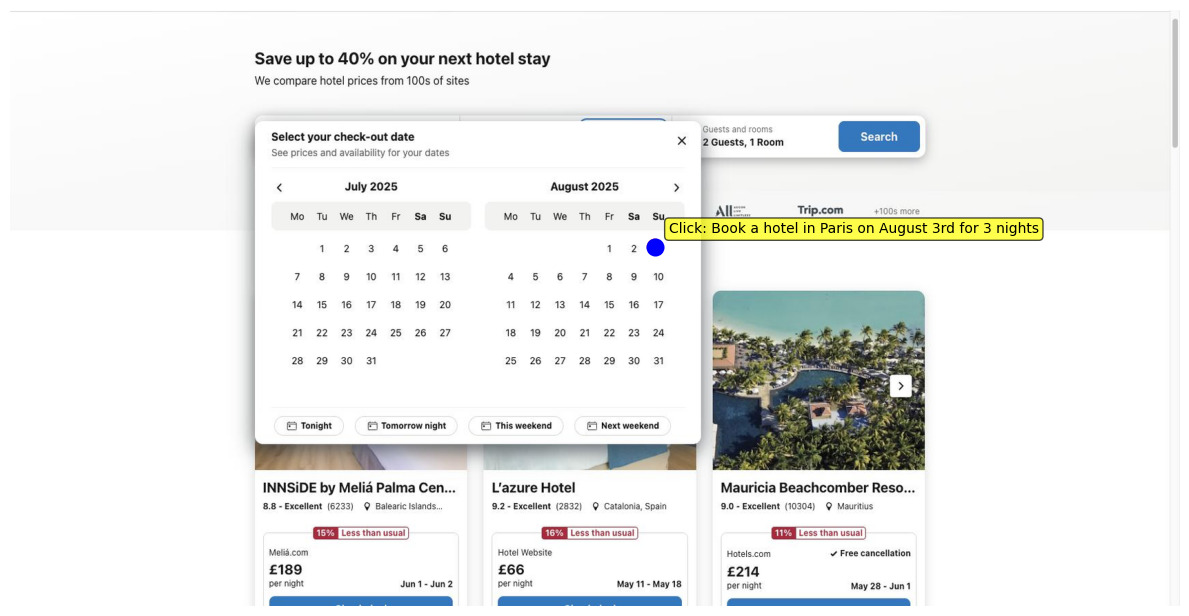

In [14]:
# Visualizing the result:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import Figure
from matplotlib.axes import Axes

def visualize_click(action, processed_img, task):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(processed_img)
    x = action.x / 1000 * processed_img.width
    y = action.y / 1000 * processed_img.height
    print(f"Predicted action: Click on '{task}' at coordinates ({x}, {y})")

    ax.plot(x, y, "bo", markersize=10, markeredgewidth=3)

    circle = patches.Circle((x, y), 10, linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(circle)

    ax.annotate(
            f"Click: {task}",
            xy=(x, y),
            xytext=(x + 20, y - 20),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
            fontsize=10,
        )
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

fig, ax = visualize_click(action, processed_image, task=task)
plt.show()


### Using ScaleCUA for Agentic Computer Use


ScaleCUA is an agentic model that can do many actions when given a task. It’s based on Qwen2.5-VL, and comes in 3B, 7B and 32B. It comes with its own configuration, so there’s a slight adjustment when loading the processor.

In [15]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "OpenGVLab/ScaleCUA-3B", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("OpenGVLab/ScaleCUA-3B", min_pixels=3136, max_pixels=2109744)


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Agentic models operating over graphical user interfaces often include their own system prompts that define “the tools” they can call. Technically, each mouse click, scrolling or typing is a tool here, so they are defined in the system prompt. We have taken this prompt from the model card.

In [16]:
SYSTEM_PROMPT = '''You are an autonomous GUI agent capable of operating on desktops, mobile devices, and web browsers. Your primary function is to analyze screen captures and perform appropriate UI actions to complete assigned tasks.
## Action Space
def click(
x: float | None = None,
y: float | None = None,
clicks: int = 1,
button: str = "left",
) -> None:
"""Clicks on the screen at the specified coordinates. The `x` and `y` parameter specify where the mouse event occurs. If not provided, the current mouse position is used. The `clicks` parameter specifies how many times to click, and the `button` parameter specifies which mouse button to use ('left', 'right', or 'middle')."""
pass
def doubleClick(
x: float | None = None,
y: float | None = None,
button: str = "left",
) -> None:
"""Performs a double click. This is a wrapper function for click(x, y, 2, 'left')."""
pass
def rightClick(x: float | None = None, y: float | None = None) -> None:
"""Performs a right mouse button click. This is a wrapper function for click(x, y, 1, 'right')."""
pass
def moveTo(x: float, y: float) -> None:
"""Move the mouse to the specified coordinates."""
pass
def dragTo(
x: float | None = None, y: float | None = None, button: str = "left"
) -> None:
"""Performs a drag-to action with optional `x` and `y` coordinates and button."""
pass
def swipe(
from_coord: tuple[float, float] | None = None,
to_coord: tuple[float, float] | None = None,
direction: str = "up",
amount: float = 0.5,
) -> None:
"""Performs a swipe action on the screen. The `from_coord` and `to_coord` specify the starting and ending coordinates of the swipe. If `to_coord` is not provided, the `direction` and `amount` parameters are used to determine the swipe direction and distance. The `direction` can be 'up', 'down', 'left', or 'right', and the `amount` specifies how far to swipe relative to the screen size (0 to 1)."""
pass
def long_press(x: float, y: float, duration: int = 1) -> None:
"""Long press on the screen at the specified coordinates. The `duration` specifies how long to hold the press in seconds."""
pass
## Input Specification
- Screenshot of the current screen + task description
## Output Format
<action>
[A set of executable action command]
</action>
## Note
- Avoid action(s) that would lead to invalid states.
- The generated action(s) must exist within the defined action space.
- The generated action(s) should be enclosed within <action></action> tags.'''


As you can see, this model isn’t limited to only clicking. We add the system prompt to the messages as follows. We give the same task to this model with the same image as the previous example.

In [17]:
messages = [
    {
      "role": "system",
      "content":[
        {
          "type": "text",
          "text": SYSTEM_PROMPT,
        }
      ]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://huggingface.co/datasets/vlmbook/images/resolve/main/calendar.jpg",
            },
            {"type": "text", "text": "Book a hotel from July 3rd to July 6th."},
        ],
    }
]


You can preprocess and infer as usual.



In [18]:
inputs = processor.apply_chat_template(
    messages, tokenize=True, return_dict=True, add_generation_prompt=True, return_tensors="pt"
)
inputs = inputs.to("cuda")
generated_ids = model.generate(**inputs, max_new_tokens=128)
input_len = len(inputs["input_ids"][0])
action_str = processor.batch_decode(generated_ids[:, input_len:], skip_special_tokens=True)
print(action_str)


['<action>\nclick(x=528, y=339)\nclick(x=635, y=339)\n</action>']


As you can see, this model adds two clicks since we have given two dates. We can parse this output and visualize the clicks.

In [19]:
import re
def parse_clicks_from_action_block(action_text):
    action_text = "\n".join(action_text)
    pattern = r"click\s*\(\s*x\s*=\s*(\d+)\s*,\s*y\s*=\s*(\d+)\s*\)"
    matches = re.findall(pattern, action_text)
    clicks = [(int(x), int(y)) for x, y in matches]
    return clicks


[(528, 339), (635, 339)]


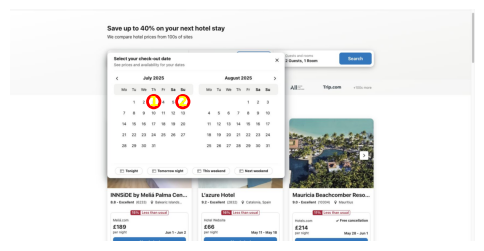

In [20]:
import matplotlib.pyplot as plt

def visualize_clicks_on_image(
    image,
    clicks,
):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    ax = plt.gca()
    if clicks:
        xs, ys = zip(*clicks)
        ax.scatter(xs, ys, s=80, edgecolors="red", facecolors="none", linewidths=2)
        for i, (x, y) in enumerate(clicks, start=1):
            ax.text(
                x,
                y,
                str(i),
                color="yellow",
                fontsize=10,
                ha="center",
                va="center",
                weight="bold",
            )
    ax.set_axis_off()
    plt.show()

clicks = parse_clicks_from_action_block(action_str)
print(clicks)
image_url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/calendar.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)

visualize_clicks_on_image(
    image=image,
    clicks=clicks,
)


**Note:** This chapter ends with vision browser example, this should be ran out of notebook.